# Text2Cypher Evaluation - Second Technical Dataset

This notebook evaluates the Text2Cypher system using the `technical_dataset_Second_COMPLETION.csv` dataset.

## Evaluation Modes:
1. **Full Schema Mode**: Uses entire schema in prompt
2. **T2CSS Filtered Mode**: Uses semantic similarity to filter top-K schema elements

## Metrics:
- **Pass@1**: Exact match between predicted and gold query results
- **KG Valid**: Query passes syntax and schema validation
- **Output Jaccard**: Jaccard similarity of query results
- **Text Metrics**: BLEU, ROUGE-L, Jaro-Winkler, Token F1
- **LLMetric**: Combined metric (ROUGE-L + Token F1 + Jaro-Winkler) / 3


## 1. Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Add backend to path
BACKEND_DIR = Path.cwd().parent / 'backend'
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

print(f"Backend directory: {BACKEND_DIR}")
print(f"Current directory: {Path.cwd()}")
print(f"Python version: {sys.version}")


Backend directory: /Users/kbahlibi/my_project/UCKG/qa-engine/text2cypher/backend
Current directory: /Users/kbahlibi/my_project/UCKG/qa-engine/text2cypher/evaluation
Python version: 3.9.6 (default, Apr 30 2025, 02:07:17) 
[Clang 17.0.0 (clang-1700.0.13.5)]


In [2]:
# Load the second technical dataset
DATASET_PATH = Path.cwd().parent / 'dataset' / 'technical_dataset_Second_COMPLETION.csv'

print(f"Loading dataset from: {DATASET_PATH}")
print(f"File exists: {DATASET_PATH.exists()}")

df = pd.read_csv(DATASET_PATH)

print(f"\n✅ Dataset loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")


Loading dataset from: /Users/kbahlibi/my_project/UCKG/qa-engine/text2cypher/dataset/technical_dataset_Second_COMPLETION.csv
File exists: True

✅ Dataset loaded successfully!
Total rows: 445
Total columns: 9

Column names:
  - Category
  - NaturalLanguageQuestion
  - CypherQuery
  - generated_question
  - ExpectedNodeLabels
  - ExpectedRelationshipTypes
  - ExpectedProperties
  - Hops
  - ExtractedPropertyValues


In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,Category,NaturalLanguageQuestion,CypherQuery,generated_question,ExpectedNodeLabels,ExpectedRelationshipTypes,ExpectedProperties,Hops,ExtractedPropertyValues
0,Node Lookup Queries,Pull the record for CVE-2021-44228.,MATCH (c:UcoCVE {label: 'CVE-2021-44228'}) RET...,What are the full details for 'CVE-2021-44228'?,"[""UcoCVE""]",[],"[""label""]",0,"[""CVE-2021-44228""]"
1,Node Lookup Queries,Get the name and description for CWE-89.,MATCH (c:UcoCWE {ucocweID: 'CWE-89'}) RETURN c...,What is the name and description for weakness ...,"[""UcoCWE""]",[],"[""ucocweID"", ""ucocweName"", ""ucodescription""]",0,"[""CWE-89""]"
2,Node Lookup Queries,Show me all data on the 'SolarWinds Orion' cam...,MATCH (c:UcoexCAMPAIGNS {ucoexNAME: 'SolarWind...,Show me all information on the 'SolarWinds Ori...,"[""UcoexCAMPAIGNS""]",[],"[""ucoexNAME""]",0,"[""SolarWinds Orion""]"
3,Node Lookup Queries,What's the description and domain for the 'Phi...,MATCH (t:UcoexMITREATTACK {ucoexNAME: 'Phishin...,What's the description and domain for the 'Phi...,"[""UcoexMITREATTACK""]",[],"[""ucoexDESCRIPTION"", ""ucoexDOMAIN"", ""ucoexNAME""]",0,"[""Phishing""]"
4,Node Lookup Queries,Pull the entry for the 'Mimikatz' tool.,MATCH (s:UcoexSOFTWARE {ucoexNAME: 'Mimikatz'}...,Find all data for the software 'Mimikatz'.,"[""UcoexSOFTWARE""]",[],"[""ucoexNAME""]",0,"[""Mimikatz""]"


## 3. Dataset Overview Statistics


DATASET BASIC STATISTICS

Total Queries: 445

Data Types:
Category                     object
NaturalLanguageQuestion      object
CypherQuery                  object
generated_question           object
ExpectedNodeLabels           object
ExpectedRelationshipTypes    object
ExpectedProperties           object
Hops                          int64
ExtractedPropertyValues      object
dtype: object

Missing Values:
  No missing values!

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Category                   445 non-null    object
 1   NaturalLanguageQuestion    445 non-null    object
 2   CypherQuery                445 non-null    object
 3   generated_question         445 non-null    object
 4   ExpectedNodeLabels         445 non-null    object
 5   ExpectedRelationshipTypes  445 non-null    object
 6   Ex

In [5]:
# Analyze category distribution
print("="*80)
print("CATEGORY DISTRIBUTION")
print("="*80)

category_counts = df['Category'].value_counts()
print(f"\nTotal Categories: {len(category_counts)}")
print(f"\nQuery Distribution by Category:")
print("-" * 60)

for cat, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{cat:<45} {count:>5} ({percentage:>5.1f}%)")

print("-" * 60)
print(f"{'TOTAL':<45} {len(df):>5} (100.0%)")


CATEGORY DISTRIBUTION

Total Categories: 9

Query Distribution by Category:
------------------------------------------------------------
Node Lookup Queries                              74 ( 16.6%)
Aggregation and Counting                         58 ( 13.0%)
Relationship Traversal Queries                   52 ( 11.7%)
Existence and Set Operations Queries             49 ( 11.0%)
Conditional and Boolean Queries                  48 ( 10.8%)
Path Queries (Variable-length)                   48 ( 10.8%)
Comparative and Ranking                          44 (  9.9%)
Graph Pattern Matching                           39 (  8.8%)
Multi-hop Queries                                33 (  7.4%)
------------------------------------------------------------
TOTAL                                           445 (100.0%)


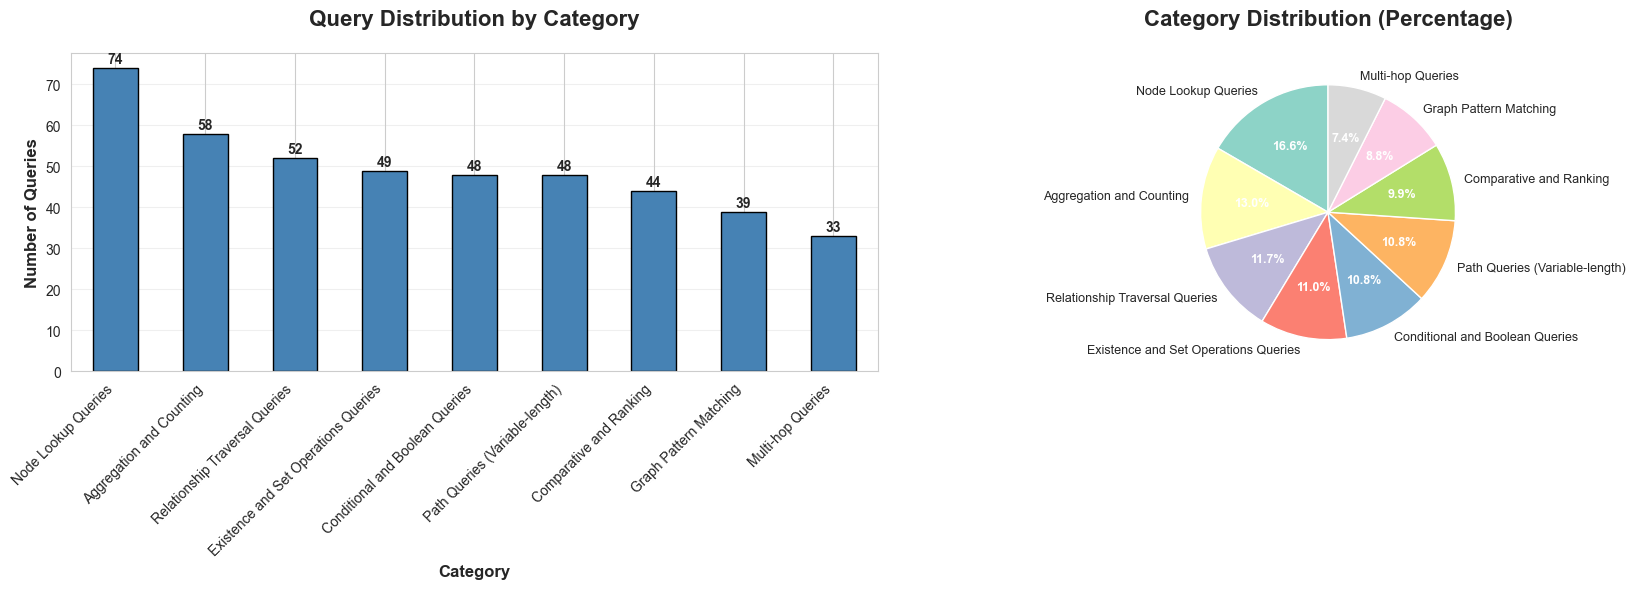

In [6]:
# Visualize category distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
ax = axes[0]
category_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Query Distribution by Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Queries', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(category_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
ax = axes[1]
colors = plt.cm.Set3(range(len(category_counts)))
wedges, texts, autotexts = ax.pie(category_counts.values, labels=category_counts.index, 
                                    autopct='%1.1f%%', startangle=90, colors=colors,
                                    textprops={'fontsize': 9})
ax.set_title('Category Distribution (Percentage)', fontsize=16, fontweight='bold', pad=20)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()


In [7]:
# Analyze query complexity by number of hops
if 'Hops' in df.columns:
    print("="*80)
    print("QUERY COMPLEXITY ANALYSIS (Number of Hops)")
    print("="*80)
    
    hops_counts = df['Hops'].value_counts().sort_index()
    print(f"\nQuery Distribution by Hops:")
    print("-" * 50)
    
    for hops, count in hops_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{hops} hop(s): {count:>4} queries ({percentage:>5.1f}%)")
    
    print("-" * 50)
    print(f"Total:     {len(df):>4} queries (100.0%)")
    
    # Statistics
    print(f"\nComplexity Statistics:")
    print(f"  - Mean hops: {df['Hops'].mean():.2f}")
    print(f"  - Median hops: {df['Hops'].median():.0f}")
    print(f"  - Min hops: {df['Hops'].min():.0f}")
    print(f"  - Max hops: {df['Hops'].max():.0f}")
    print(f"  - Std dev: {df['Hops'].std():.2f}")
else:
    print("⚠️ 'Hops' column not found in dataset")


QUERY COMPLEXITY ANALYSIS (Number of Hops)

Query Distribution by Hops:
--------------------------------------------------
0 hop(s):  173 queries ( 38.9%)
1 hop(s):  180 queries ( 40.4%)
2 hop(s):   75 queries ( 16.9%)
3 hop(s):   12 queries (  2.7%)
4 hop(s):    1 queries (  0.2%)
5 hop(s):    1 queries (  0.2%)
6 hop(s):    3 queries (  0.7%)
--------------------------------------------------
Total:      445 queries (100.0%)

Complexity Statistics:
  - Mean hops: 0.88
  - Median hops: 1
  - Min hops: 0
  - Max hops: 6
  - Std dev: 0.94


In [ ]:
# Visualize hops distribution
if 'Hops' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Bar chart
    ax = axes[0]
    hops_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black', width=0.7)
    ax.set_title('Query Distribution by Complexity (Hops)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Number of Hops', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Queries', fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(hops_counts.values):
        ax.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')
    
    # Histogram with KDE
    ax = axes[1]
    ax.hist(df['Hops'], bins=range(int(df['Hops'].min()), int(df['Hops'].max())+2), 
            color='coral', edgecolor='black', alpha=0.7)
    ax.set_title('Query Complexity Distribution', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Number of Hops', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_hops = df['Hops'].mean()
    ax.axvline(mean_hops, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_hops:.2f}')
    ax.legend()
    
    plt.tight_layout()
    plt.show()


## 6. Category vs Complexity Cross-Analysis


In [8]:
# Analyze average complexity per category
if 'Hops' in df.columns:
    print("="*80)
    print("CATEGORY vs COMPLEXITY ANALYSIS")
    print("="*80)
    
    category_complexity = df.groupby('Category')['Hops'].agg(['mean', 'min', 'max', 'count']).round(2)
    category_complexity = category_complexity.sort_values('mean', ascending=False)
    
    print(f"\nAverage Complexity by Category:")
    print("-" * 80)
    print(f"{'Category':<45} {'Avg Hops':<12} {'Min':<8} {'Max':<8} {'Count':<8}")
    print("-" * 80)
    
    for cat, row in category_complexity.iterrows():
        print(f"{cat:<45} {row['mean']:>10.2f}  {int(row['min']):>6}  {int(row['max']):>6}  {int(row['count']):>6}")
    
    print("-" * 80)


CATEGORY vs COMPLEXITY ANALYSIS

Average Complexity by Category:
--------------------------------------------------------------------------------
Category                                      Avg Hops     Min      Max      Count   
--------------------------------------------------------------------------------
Graph Pattern Matching                              2.31       1       6      39
Multi-hop Queries                                   2.24       1       6      33
Relationship Traversal Queries                      1.04       1       2      52
Path Queries (Variable-length)                      1.00       1       1      48
Existence and Set Operations Queries                0.88       0       3      49
Comparative and Ranking                             0.73       0       6      44
Conditional and Boolean Queries                     0.52       0       2      48
Aggregation and Counting                            0.45       0       1      58
Node Lookup Queries                    

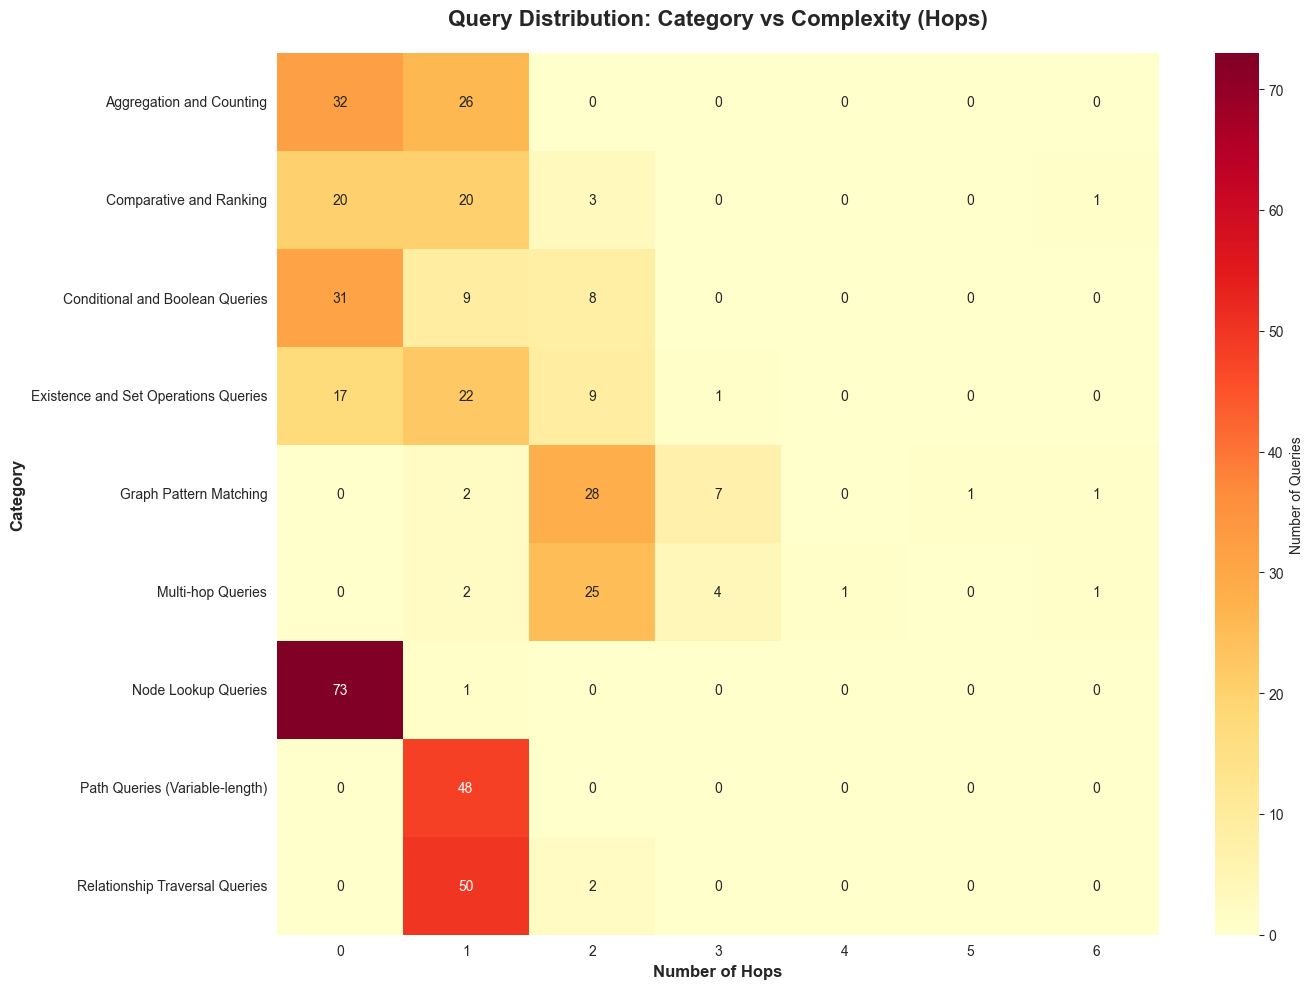

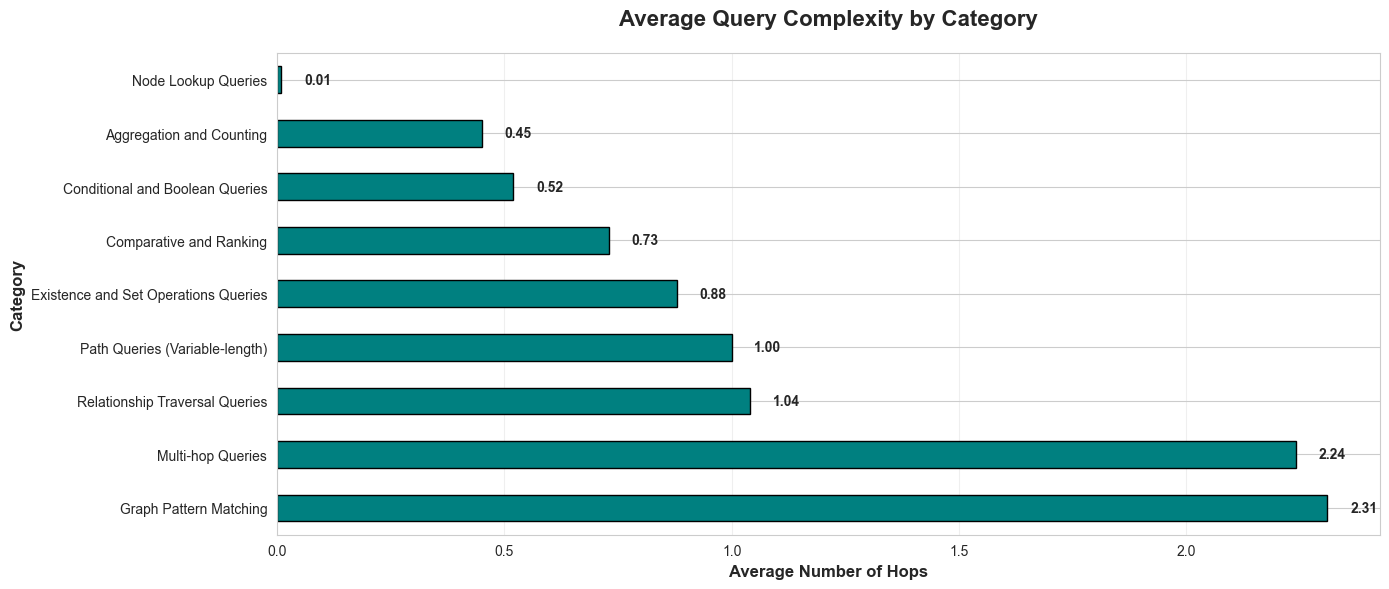

In [9]:
# Visualize category vs complexity
if 'Hops' in df.columns:
    # Heatmap: Category vs Hops
    pivot_table = pd.crosstab(df['Category'], df['Hops'])
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Number of Queries'})
    plt.title('Query Distribution: Category vs Complexity (Hops)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of Hops', fontsize=12, fontweight='bold')
    plt.ylabel('Category', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Bar chart: Average hops per category
    plt.figure(figsize=(14, 6))
    category_complexity['mean'].plot(kind='barh', color='teal', edgecolor='black')
    plt.title('Average Query Complexity by Category', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Average Number of Hops', fontsize=12, fontweight='bold')
    plt.ylabel('Category', fontsize=12, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(category_complexity['mean'].values):
        plt.text(v + 0.05, i, f'{v:.2f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


In [11]:
# Analyze expected node labels and relationships
import ast

print("="*80)
print("SCHEMA ELEMENTS ANALYSIS")
print("="*80)

# Parse ExpectedNodeLabels
if 'ExpectedNodeLabels' in df.columns:
    all_node_labels = []
    for labels_str in df['ExpectedNodeLabels'].dropna():
        try:
            labels = ast.literal_eval(labels_str)
            all_node_labels.extend(labels)
        except:
            pass
    
    node_label_counts = pd.Series(all_node_labels).value_counts()
    print(f"\nMost Common Node Labels (Top 15):")
    print("-" * 50)
    for label, count in node_label_counts.head(15).items():
        percentage = (count / len(df)) * 100
        print(f"{label:<30} {count:>5} ({percentage:>5.1f}%)")

# Parse ExpectedRelationshipTypes
if 'ExpectedRelationshipTypes' in df.columns:
    all_rel_types = []
    for rels_str in df['ExpectedRelationshipTypes'].dropna():
        try:
            rels = ast.literal_eval(rels_str)
            all_rel_types.extend(rels)
        except:
            pass
    
    rel_type_counts = pd.Series(all_rel_types).value_counts()
    print(f"\n\nMost Common Relationship Types (Top 15):")
    print("-" * 50)
    for rel, count in rel_type_counts.head(15).items():
        percentage = (count / len(df)) * 100
        print(f"{rel:<30} {count:>5} ({percentage:>5.1f}%)")


SCHEMA ELEMENTS ANALYSIS

Most Common Node Labels (Top 15):
--------------------------------------------------
UcoexGROUPS                      115 ( 25.8%)
UcoexMITREATTACK                 111 ( 24.9%)
UcoCVE                           100 ( 22.5%)
UcoCWE                            95 ( 21.3%)
UcoexSOFTWARE                     72 ( 16.2%)
UcoexCAMPAIGNS                    61 ( 13.7%)
UcoexCAPEC                        45 ( 10.1%)
UcoVulnerability                  45 ( 10.1%)
UcoExploitTarget                  35 (  7.9%)
UcoexMITIGATIONS                  29 (  6.5%)
UcoexCPE                          28 (  6.3%)
UcoexObservedExample              27 (  6.1%)
UcoexMITRED3FEND                  20 (  4.5%)
UcoexTACTICS                      17 (  3.8%)


Most Common Relationship Types (Top 15):
--------------------------------------------------
UCOEXGROUPUSESTECHNIQUE           47 ( 10.6%)
UCOEXGROUPUSESSOFTWARE            33 (  7.4%)
UCOEXCAMPAIGNUSESSOFTWARE         22 (  4.9%)
UCOHASCVE_ID 

In [ ]:
# Visualize schema elements
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Node labels
if 'ExpectedNodeLabels' in df.columns and len(all_node_labels) > 0:
    ax = axes[0]
    node_label_counts.head(15).plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title('Top 15 Most Common Node Labels', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_ylabel('Node Label', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(node_label_counts.head(15).values):
        ax.text(v + 1, i, str(v), va='center', fontweight='bold')

# Relationship types
if 'ExpectedRelationshipTypes' in df.columns and len(all_rel_types) > 0:
    ax = axes[1]
    rel_type_counts.head(15).plot(kind='barh', ax=ax, color='lightcoral', edgecolor='black')
    ax.set_title('Top 15 Most Common Relationship Types', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_ylabel('Relationship Type', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(rel_type_counts.head(15).values):
        ax.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 8. Sample Queries by Category


In [12]:
# Show sample queries from each category
print("="*80)
print("SAMPLE QUERIES BY CATEGORY")
print("="*80)

for category in df['Category'].unique()[:5]:  # Show first 5 categories
    print(f"\n{'='*80}")
    print(f"Category: {category}")
    print(f"{'='*80}")
    
    category_df = df[df['Category'] == category]
    sample = category_df.head(2)  # Show 2 examples per category
    
    for idx, row in sample.iterrows():
        print(f"\nExample {idx + 1}:")
        print(f"  Question: {row['NaturalLanguageQuestion']}")
        if 'Hops' in row:
            print(f"  Complexity: {int(row['Hops'])} hop(s)")
        print(f"  Cypher: {row['CypherQuery'][:100]}...")
        print("-" * 80)


SAMPLE QUERIES BY CATEGORY

Category: Node Lookup Queries

Example 1:
  Question: Pull the record for CVE-2021-44228.
  Complexity: 0 hop(s)
  Cypher: MATCH (c:UcoCVE {label: 'CVE-2021-44228'}) RETURN c...
--------------------------------------------------------------------------------

Example 2:
  Question: Get the name and description for CWE-89.
  Complexity: 0 hop(s)
  Cypher: MATCH (c:UcoCWE {ucocweID: 'CWE-89'}) RETURN c.ucocweName, c.ucodescription...
--------------------------------------------------------------------------------

Category: Relationship Traversal Queries

Example 11:
  Question: Show me campaigns linked to the Lazarus Group.
  Complexity: 1 hop(s)
  Cypher: MATCH (g:UcoexGROUPS {ucoexNAME: 'Lazarus Group'})<-[:UCOEXATTRIBUTEDTO]-(c:UcoexCAMPAIGNS) RETURN c...
--------------------------------------------------------------------------------

Example 12:
  Question: What MITRE ATT&CK TTPs are associated with FIN7?
  Complexity: 1 hop(s)
  Cypher: MATCH (g:UcoexGR

## 9. Dataset Summary Report


In [14]:
# Generate comprehensive summary
print("="*80)
print("DATASET SUMMARY REPORT")
print("="*80)

print(f"\n📊 OVERALL STATISTICS")
print(f"  • Total Queries: {len(df)}")
print(f"  • Total Categories: {df['Category'].nunique()}")
print(f"  • Date Range: {DATASET_PATH.name}")

if 'Hops' in df.columns:
    print(f"\n🔗 COMPLEXITY METRICS")
    print(f"  • Average Complexity: {df['Hops'].mean():.2f} hops")
    print(f"  • Complexity Range: {int(df['Hops'].min())} - {int(df['Hops'].max())} hops")
    print(f"  • Most Common: {int(df['Hops'].mode()[0])} hop(s)")

print(f"\n📁 CATEGORY BREAKDOWN")
print(f"  • Largest Category: {category_counts.index[0]} ({category_counts.values[0]} queries)")
print(f"  • Smallest Category: {category_counts.index[-1]} ({category_counts.values[-1]} queries)")
print(f"  • Average per Category: {len(df) / df['Category'].nunique():.1f} queries")

if 'ExpectedNodeLabels' in df.columns and len(all_node_labels) > 0:
    print(f"\n🏷️  SCHEMA COVERAGE")
    print(f"  • Unique Node Labels: {len(node_label_counts)}")
    print(f"  • Most Used Node: {node_label_counts.index[0]} ({node_label_counts.values[0]} times)")

if 'ExpectedRelationshipTypes' in df.columns and len(all_rel_types) > 0:
    print(f"  • Unique Relationships: {len(rel_type_counts)}")
    print(f"  • Most Used Relationship: {rel_type_counts.index[0]} ({rel_type_counts.values[0]} times)")

print(f"\n✅ Dataset is ready for evaluation!")
print("="*80)


DATASET SUMMARY REPORT

📊 OVERALL STATISTICS
  • Total Queries: 445
  • Total Categories: 9
  • Date Range: technical_dataset_Second_COMPLETION.csv

🔗 COMPLEXITY METRICS
  • Average Complexity: 0.88 hops
  • Complexity Range: 0 - 6 hops
  • Most Common: 1 hop(s)

📁 CATEGORY BREAKDOWN
  • Largest Category: Node Lookup Queries (74 queries)
  • Smallest Category: Multi-hop Queries (33 queries)
  • Average per Category: 49.4 queries

🏷️  SCHEMA COVERAGE
  • Unique Node Labels: 14
  • Most Used Node: UcoexGROUPS (115 times)
  • Unique Relationships: 16
  • Most Used Relationship: UCOEXGROUPUSESTECHNIQUE (47 times)

✅ Dataset is ready for evaluation!
